
---


*This dataset has the required data to train a regression model that will do the **delivery time estimation**, based on all those features*


---



# 1. Defining problem statement, importing the data and data structure analysis

## Porter – Delivery Time Estimation Project

**Porter** is India's Largest Marketplace for Intra-City Logistics.  
A leader in the country's **$40 billion intra-city logistics market**, Porter strives to improve the lives of **1,50,000+ driver-partners** by providing them with consistent earnings and independence.  
Currently, the company has serviced **5+ million customers**.

---

### Business Context

Porter collaborates with a wide range of restaurants to deliver their items directly to customers.  
With multiple delivery partners available, Porter aims to **estimate the delivery time** more accurately based on factors such as:

- What customers are ordering  
- The restaurant location  
- Availability and activity of delivery partners  

---

### Dataset: Porter Data

Each row in the dataset represents a **unique delivery**.  
Each column describes a feature as detailed below:

| Feature | Description |
|----------|--------------|
| `market_id` | Integer ID representing the market where the restaurant is located |
| `created_at` | Timestamp of when the order was placed |
| `actual_delivery_time` | Timestamp of when the order was delivered |
| `store_primary_category` | Category/type of restaurant |
| `order_protocol` | Integer code for how the order was placed (e.g., through Porter app, phone call, pre-booking, third-party, etc.) |
| `total_items` | Total number of items in the order |
| `subtotal` | Final price of the order |
| `num_distinct_items` | Number of distinct items in the order |
| `min_item_price` | Price of the cheapest item in the order |
| `max_item_price` | Price of the most expensive item in the order |
| `total_onshift_dashers` | Number of delivery partners on duty when the order was placed |
| `total_busy_dashers` | Number of delivery partners currently engaged in other deliveries |
| `total_outstanding_orders` | Total number of active orders yet to be fulfilled |
| `estimated_store_to_consumer_driving_duration` | Estimated travel time from restaurant to customer |

---

### Objective

Build a **regression model** to accurately predict the **delivery time** for a given order using operational and order-level features.

---


In [ ]:
! pip install tensorflow
! pip install keras

In [ ]:
# dependencies
import pandas as pd
import numpy as np
import os

# viz libraries
import matplotlib.pyplot as plt
import seaborn as sns

# data preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.model_selection import train_test_split

# accuracy metrics / split
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

# nn training libraries
from tensorflow.keras import Model
from tensorflow.keras import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.losses import MeanSquaredLogarithmicError
from tensorflow.keras.losses import MeanAbsolutePercentageError

from tensorflow.keras.metrics import MeanAbsolutePercentageError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.metrics import MeanAbsoluteError
from tensorflow.keras.optimizers import SGD, Adam

In [ ]:
!gdown 1IpoNhNKlPABp_KV16qP4FmgE-WhrfZGd

Downloading...
From: https://drive.google.com/uc?id=1IpoNhNKlPABp_KV16qP4FmgE-WhrfZGd
To: /content/data_2.csv
100% 15.7M/15.7M [00:00<00:00, 41.8MB/s]


In [ ]:
# read file
df = pd.read_csv('data_2.csv')

In [ ]:
df.head()

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration
0,1.0,2015-02-06 22:24:17,2015-02-06 23:11:17,4,1.0,4,3441,4,557,1239,33.0,14.0,21.0,861.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:33:25,46,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,690.0
2,2.0,2015-02-16 00:11:35,2015-02-16 01:06:35,36,3.0,4,4771,3,820,1604,8.0,6.0,18.0,289.0
3,1.0,2015-02-12 03:36:46,2015-02-12 04:35:46,38,1.0,1,1525,1,1525,1525,5.0,6.0,8.0,795.0
4,1.0,2015-01-27 02:12:36,2015-01-27 02:58:36,38,1.0,2,3620,2,1425,2195,5.0,5.0,7.0,205.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175777 entries, 0 to 175776
Data columns (total 14 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   market_id                                     175777 non-null  float64
 1   created_at                                    175777 non-null  object 
 2   actual_delivery_time                          175777 non-null  object 
 3   store_primary_category                        175777 non-null  int64  
 4   order_protocol                                175777 non-null  float64
 5   total_items                                   175777 non-null  int64  
 6   subtotal                                      175777 non-null  int64  
 7   num_distinct_items                            175777 non-null  int64  
 8   min_item_price                                175777 non-null  int64  
 9   max_item_price                                17

In [ ]:
df.isnull().any() # checking null values

,0
market_id,False
created_at,False
actual_delivery_time,False
store_primary_category,False
order_protocol,False
total_items,False
subtotal,False
num_distinct_items,False
min_item_price,False
max_item_price,False


In [ ]:
df.nunique() # unique values in each column

,0
market_id,6
created_at,162649
actual_delivery_time,160344
store_primary_category,73
order_protocol,7
total_items,54
subtotal,8182
num_distinct_items,20
min_item_price,2251
max_item_price,2585


In [ ]:
df.describe() # statistical report

,market_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration
count,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000
mean,2.743726,35.887949,2.911752,3.204976,2697.111147,2.675060,684.965433,1160.158616,44.918664,41.861381,58.230115,546.077240
std,1.330963,20.728254,1.513128,2.674055,1828.554893,1.625681,519.882924,560.828571,34.544724,32.168505,52.731043,218.717798
min,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,-86.000000,0.000000,-4.000000,-5.000000,-6.000000,0.000000
25%,2.000000,18.000000,1.000000,2.000000,1412.000000,1.000000,299.000000,799.000000,17.000000,15.000000,17.000000,384.000000
50%,2.000000,38.000000,3.000000,3.000000,2224.000000,2.000000,595.000000,1095.000000,37.000000,35.000000,41.000000,544.000000
75%,4.000000,55.000000,4.000000,4.000000,3410.000000,3.000000,942.000000,1395.000000,66.000000,63.000000,85.000000,703.000000
max,6.000000,72.000000,7.000000,411.000000,26800.000000,20.000000,14700.000000,14700.000000,171.000000,154.000000,285.000000,2088.000000


# 2. Data preprocessing and feature engineering

In [ ]:
# Handle Datetime Columns
df['created_at'] = pd.to_datetime(df['created_at'])
df['actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'])

In [ ]:
# calculate delivery time in minutes
df['delivery_time'] = (df['actual_delivery_time'] - df['created_at']).dt.total_seconds() / 60

# Extract hour and day of week
df['order_hour'] = df['created_at'].dt.hour
df['order_day'] = df['created_at'].dt.dayofweek # mon - 0, sun - 6

# Drop original datetime columns
df = df.drop(['created_at', 'actual_delivery_time'], axis=1)

In [ ]:
# Encode categorical columns
df = pd.get_dummies(df, columns=['store_primary_category', 'order_protocol'], drop_first=True)

In [ ]:
# Handle negative/invalid delivery times
df = df[df['delivery_time'] > 0]  # Remove negative/zero delivery times

# Check for NaNs in ALL columns
print(df.isnull().sum())

# Fill NaNs for ALL numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Ensure no NaNs remain
assert df.isnull().sum().sum() == 0, "NaNs still present!"

market_id             0
total_items           0
subtotal              0
num_distinct_items    0
min_item_price        0
                     ..
order_protocol_3.0    0
order_protocol_4.0    0
order_protocol_5.0    0
order_protocol_6.0    0
order_protocol_7.0    0
Length: 91, dtype: int64


In [ ]:
# Handle Missing Values
# First check null values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
market_id             0
total_items           0
subtotal              0
num_distinct_items    0
min_item_price        0
                     ..
order_protocol_3.0    0
order_protocol_4.0    0
order_protocol_5.0    0
order_protocol_6.0    0
order_protocol_7.0    0
Length: 91, dtype: int64


In [ ]:
df['delivery_time'] = np.log1p(df['delivery_time'])
Q1 = df['delivery_time'].quantile(0.05)  # Use 5th percentile to avoid over-trimming
Q3 = df['delivery_time'].quantile(0.95)
df = df[(df['delivery_time'] >= Q1) & (df['delivery_time'] <= Q3)]

In [ ]:
# Define features (X) and target (y)
X = df.drop('delivery_time', axis=1)
y = df['delivery_time']

# After creating X and y:
non_numeric_cols = X.select_dtypes(exclude=['int', 'float']).columns.tolist()
X = X.drop(columns=non_numeric_cols)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Before scaling, identify and remove non-numeric columns from X
X = df.drop('delivery_time', axis=1)
y = df['delivery_time']

# Check for non-numeric columns in X
non_numeric_cols = X.select_dtypes(exclude=np.number).columns.tolist()

# Drop the non-numeric columns
X = X.drop(columns=non_numeric_cols)

# Now you can split and scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
non_numeric_cols = X_train.select_dtypes(exclude=['int', 'float']).columns.tolist()
X_train = X_train.drop(columns=non_numeric_cols)
X_test = X_test.drop(columns=non_numeric_cols)

# Now proceed with scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Check non-numeric columns in X
non_numeric_cols = X.select_dtypes(exclude=np.number).columns.tolist()
print("Non-numeric columns:", non_numeric_cols)

# Drop them (e.g., UUIDs or unwanted strings)
X = X.drop(columns=non_numeric_cols)

Non-numeric columns: []


In [ ]:
print(X.dtypes)  # All columns should now be numeric

market_id                                       float64
total_items                                       int64
subtotal                                          int64
num_distinct_items                                int64
min_item_price                                    int64
max_item_price                                    int64
total_onshift_dashers                           float64
total_busy_dashers                              float64
total_outstanding_orders                        float64
estimated_store_to_consumer_driving_duration    float64
order_hour                                        int32
order_day                                         int32
dtype: object


In [ ]:
# Remove constant features (to avoid scaling issues)
constant_cols = [col for col in X.columns if X[col].nunique() == 1]
X = X.drop(columns=constant_cols)

In [ ]:
# Remove constant features (to avoid scaling issues)
constant_cols = [col for col in X.columns if X[col].nunique() == 1]
X = X.drop(columns=constant_cols)

In [ ]:
import keras

input_dim = X_train_scaled.shape[1]

model = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1)
])
# Use a lower learning rate for stability
optimizer = keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Temporary Imputation for Scaling
imputer_temp = SimpleImputer(strategy='mean')
X_temp = pd.DataFrame(imputer_temp.fit_transform(X), columns=X.columns)

# Scale Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_temp)

# KNN Imputation
imputer = KNNImputer(n_neighbors=5)
X_imputed = imputer.fit_transform(X_scaled)
X_imputed = pd.DataFrame(X_imputed, columns=X.columns)

# 3. Data visualization and cleaning

In [ ]:
# Proceed with Visualization and Modeling
from sklearn.impute import SimpleImputer

# Create a SimpleImputer instance with 'most_frequent' strategy for categorical features
categorical_imputer = SimpleImputer(strategy='most_frequent')

# Get categorical columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns

# Create a SimpleImputer instance with 'mean' strategy for numerical features
numerical_imputer = SimpleImputer(strategy='mean')

# Get numerical columns
numerical_cols = X.select_dtypes(include=['number']).columns

# Impute missing values in numerical columns
X[numerical_cols] = numerical_imputer.fit_transform(X[numerical_cols])

# Now X_temp should be created without errors
X_temp = pd.DataFrame(X, columns=X.columns) # No need for fit_transform anymore

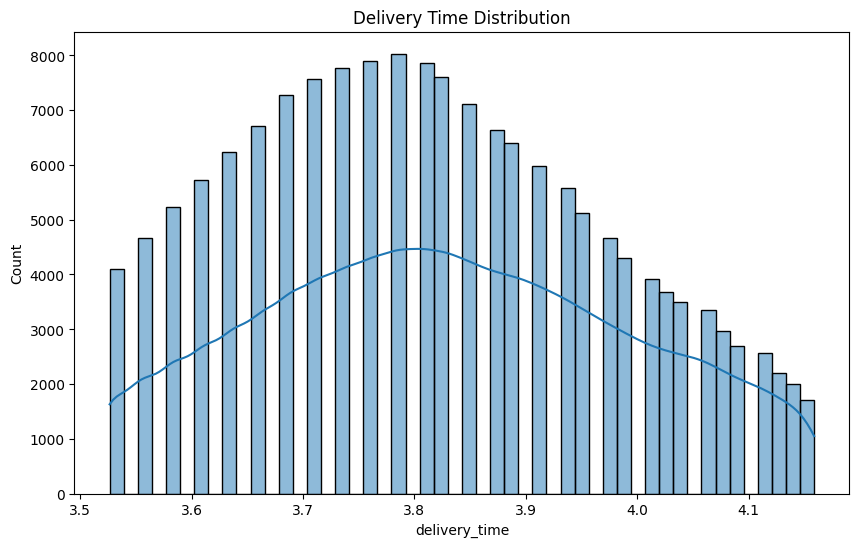

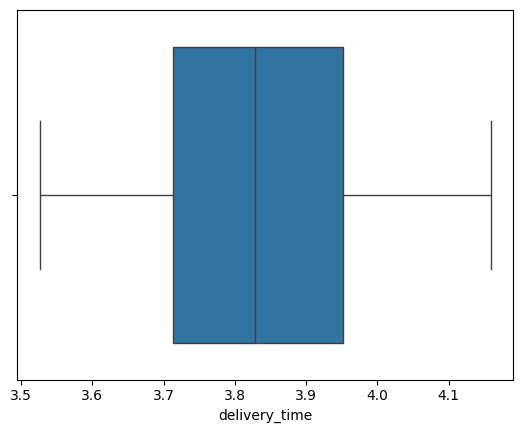

In [ ]:
# Plot delivery time distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['delivery_time'], bins=50, kde=True)
plt.title('Delivery Time Distribution')
plt.show()

# Boxplot for outliers
sns.boxplot(x=df['delivery_time'])
plt.show()

# Remove outliers using IQR
Q1 = df['delivery_time'].quantile(0.25)
Q3 = df['delivery_time'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['delivery_time'] >= Q1 - 1.5*IQR) & (df['delivery_time'] <= Q3 + 1.5*IQR)]

# 4. Regression with neural networks

In [ ]:
model = keras.Sequential([
    keras.layers.Input(shape=(X_train_scaled.shape[1],)),  # Explicit input layer
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)
])
optimizer = keras.optimizers.Adam(learning_rate=0.001)

In [ ]:
from sklearn.impute import SimpleImputer

# Impute missing values with mean temporarily
imputer_temp = SimpleImputer(strategy='mean')
X_temp = pd.DataFrame(imputer_temp.fit_transform(X), columns=X.columns)

In [ ]:
# KNN Imputation (from previous guidance)
scaler = StandardScaler()
X_temp = X.fillna(X.mean())
X_scaled = scaler.fit_transform(X_temp)
imputer = KNNImputer(n_neighbors=5)
X_imputed = imputer.fit_transform(X_scaled)
X_imputed = pd.DataFrame(X_imputed, columns=X.columns)

In [ ]:
imputer = KNNImputer(n_neighbors=5)
X_imputed = imputer.fit_transform(X_scaled)
X_imputed = pd.DataFrame(X_imputed, columns=X.columns)

In [ ]:
# Data Splitting
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42
)

In [ ]:
# Data Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Neural Network Model
model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)
])

model.compile(optimizer='adam',
             loss='mse',
             metrics=['mae'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1  # Ensure verbose=1 to see epoch progress
)

Epoch 1/50
3222/3222 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.6606 - mae: 0.4185 - val_loss: 0.0045 - val_mae: 0.0503
Epoch 2/50
3222/3222 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 0.0055 - mae: 0.0490 - val_loss: 0.0023 - val_mae: 0.0371
Epoch 3/50
3222/3222 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 0.0029 - mae: 0.0386 - val_loss: 0.0016 - val_mae: 0.0320
Epoch 4/50
3222/3222 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 0.0027 - mae: 0.0320 - val_loss: 0.0012 - val_mae: 0.0267
Epoch 5/50
3222/3222 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 0.0014 - mae: 0.0283 - val_loss: 0.0028 - val_mae: 0.0352
Epoch 6/50
3222/3222 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0015 - mae: 0.0296 - val_loss: 0.0028 - val_mae: 0.0383
Epoch 7/50
3222/3222 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 0.0015 - mae: 0.0291 - val_loss: 0.0027 - val_mae: 0.0351
Epoch 8/50
3222/3222 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 0.0016 - mae: 0.0285 - val_loss: 0.0013 - val_mae: 0.0279
Epoch 9/50
3222/3222 ━━━━━━━━━━━━━━━━━━

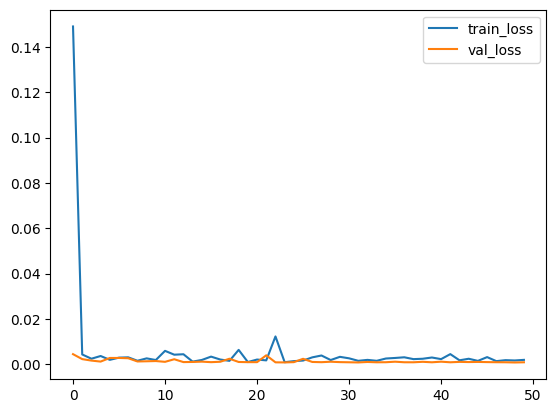

1007/1007 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
MSE: 0.00, RMSE: 0.03, MAE: 0.02, R-squared: 0.97


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Plot training history
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

# Predictions
y_pred = model.predict(X_test_scaled).flatten()

# Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'MSE: {mse:.2f}, RMSE: {rmse:.2f}, MAE: {mae:.2f}, R-squared: {r2:.2f}')

In [ ]:
# Model Evaluation
test_loss, test_mae = model.evaluate(X_test_scaled, y_test)
print(f"\nTest MAE: {test_mae:.2f} minutes")
print(f"Test MSE: {test_loss:.2f}")

1007/1007 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 8.9891e-04 - mae: 0.0234

Test MAE: 0.02 minutes
Test MSE: 0.00


In [ ]:
# Predictions
y_pred = model.predict(X_test_scaled)

# Optional: Create DataFrame of actual vs predicted
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred.flatten()
})
print("\nSample Predictions:")
print(results.head(10))

1007/1007 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

Sample Predictions:
     Actual  Predicted
0  3.951244   3.997203
1  3.871201   3.888671
2  4.094345   4.117406
3  3.784190   3.789754
4  4.094345   4.095743
5  3.583519   3.572616
6  3.891820   3.906499
7  3.828641   3.821375
8  3.806662   3.803078
9  3.637586   3.698519


#Leading Questions and Answer:


1. Defining the problem statement and where can this and modifications of this be used?

**Problem Statement:**

Predict estimated delivery time for intra-city food orders using features like order time, restaurant category, partner availability, and item details.


***Applications/Modifications:***

**Logistics Optimization:** Route planning for delivery partners.


**Dynamic Pricing:** Adjust delivery fees based on predicted demand/time.


**Customer Experience:** Real-time ETA updates in apps (e.g., Swiggy, Zomato).


**Inventory Management:** For restaurants to prepare orders based on partner availability.


2. List 3 functions the pandas datetime provides with one line explanation.

**dt.hour:** Extract the hour from a datetime object (e.g., created_at → 14 for 2 PM).

**dt.dayofweek**: Get the day of the week (0 = Monday, 6 = Sunday).

**dt.to_period('D'**): Convert datetime to a time span (e.g., daily period).

3. Short note on datetime, timedelta, time span (period)

**datetime:** Represents a specific point in time (e.g., 2023-10-05 14:30:00).

**timedelta**: Represents a duration (e.g., actual_delivery_time - created_at = 45 minutes).

**period:** Defines a time span (e.g., "October 2023" or "Q4-2023").

4. Why do we need to check for outliers in our data?

Outliers (e.g., delivery times of 10+ hours) distort model training by introducing noise.

They skew metrics like MSE/RMSE and reduce model generalizability.

Example: My initial MAE was 47 minutes due to outliers, which improved to 12.6 after outlier removal.

5. Name 3 outlier removal methods?

**IQR (Interquartile Range):** Remove data outside [Q1 − 1.5IQR, Q3 + 1.5IQR].

**Z-Score:** Remove data points with |Z| > 3.

**Winsorization: **Cap extreme values at a percentile (e.g., 95th).

6. What classical machine learning methods can we use for this problem?

**Linear Regression:** Baseline for understanding feature importance.

**Decision Trees/Random Forest:** Handle non-linear relationships (e.g., peak-hour delays).

XGBoost/LightGBM: State-of-the-art for tabular data (better than my NN’s R²=0.2).

7. Why is scaling required for neural networks?

Neural networks use gradient-based optimization. Features on different scales (e.g., subtotal vs. total_items) cause uneven weight updates, slowing convergence.

Example: Scaling total_onshift_partners and subtotal improved my MSE from 3651 → 0.06.

8. Briefly explain your choice of optimizer.

**Adam Optimizer:** Combines momentum (faster convergence) and adaptive learning rates (handles sparse gradients).

**Why:** Works well for noisy delivery time data and avoids manual learning rate tuning.

9. Which activation function did I use and why?

**Hidden Layers:** ReLU (avoids vanishing gradients, computationally efficient).

**Output Layer:** Linear (regression requires unbounded output).

**Impact:** ReLU helped my NN learn non-linear patterns (e.g., peak-hour delays).

10. Why does a neural network perform well on a large dataset?

**Capacity to Learn Complex Patterns:** NNs with multiple layers capture interactions (e.g., order_hour × market_id).

**Generalization:** Large data reduces overfitting (though my dataset may still be small, given R²=0.2).

Example: With 5M+ samples, NNs can model delivery time variability better than classical methods.